In [1]:
%load_ext autoreload
%autoreload 2

import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')
from utils import smooth_curve
from Plume import plume_dataset
from Viz import show_images, create_axes_grid
from Velocity import VelocityCalculator

In [2]:
plume_ds = plume_dataset(file_path='../datasets/LYW152_YichenGuo_JulianGoddy_03072024.h5', group_name='PLD_Plumes')
plume_ds.show_dataset_name()
plumes = plume_ds.load_plumes('1-BaTiO3')

position_range = (34, 367)
start_position = (29, 126)
threshold = 100
time_interval = 500e-9 # 500ns
V = VelocityCalculator(time_interval, position_range, start_position, threshold=50)
time, plume_positions, plume_distances, plume_velocities = V.velocity_one_func(plumes)

<KeysViewHDF5 ['1-BaTiO3', '1-BaTiO3_Pre']>


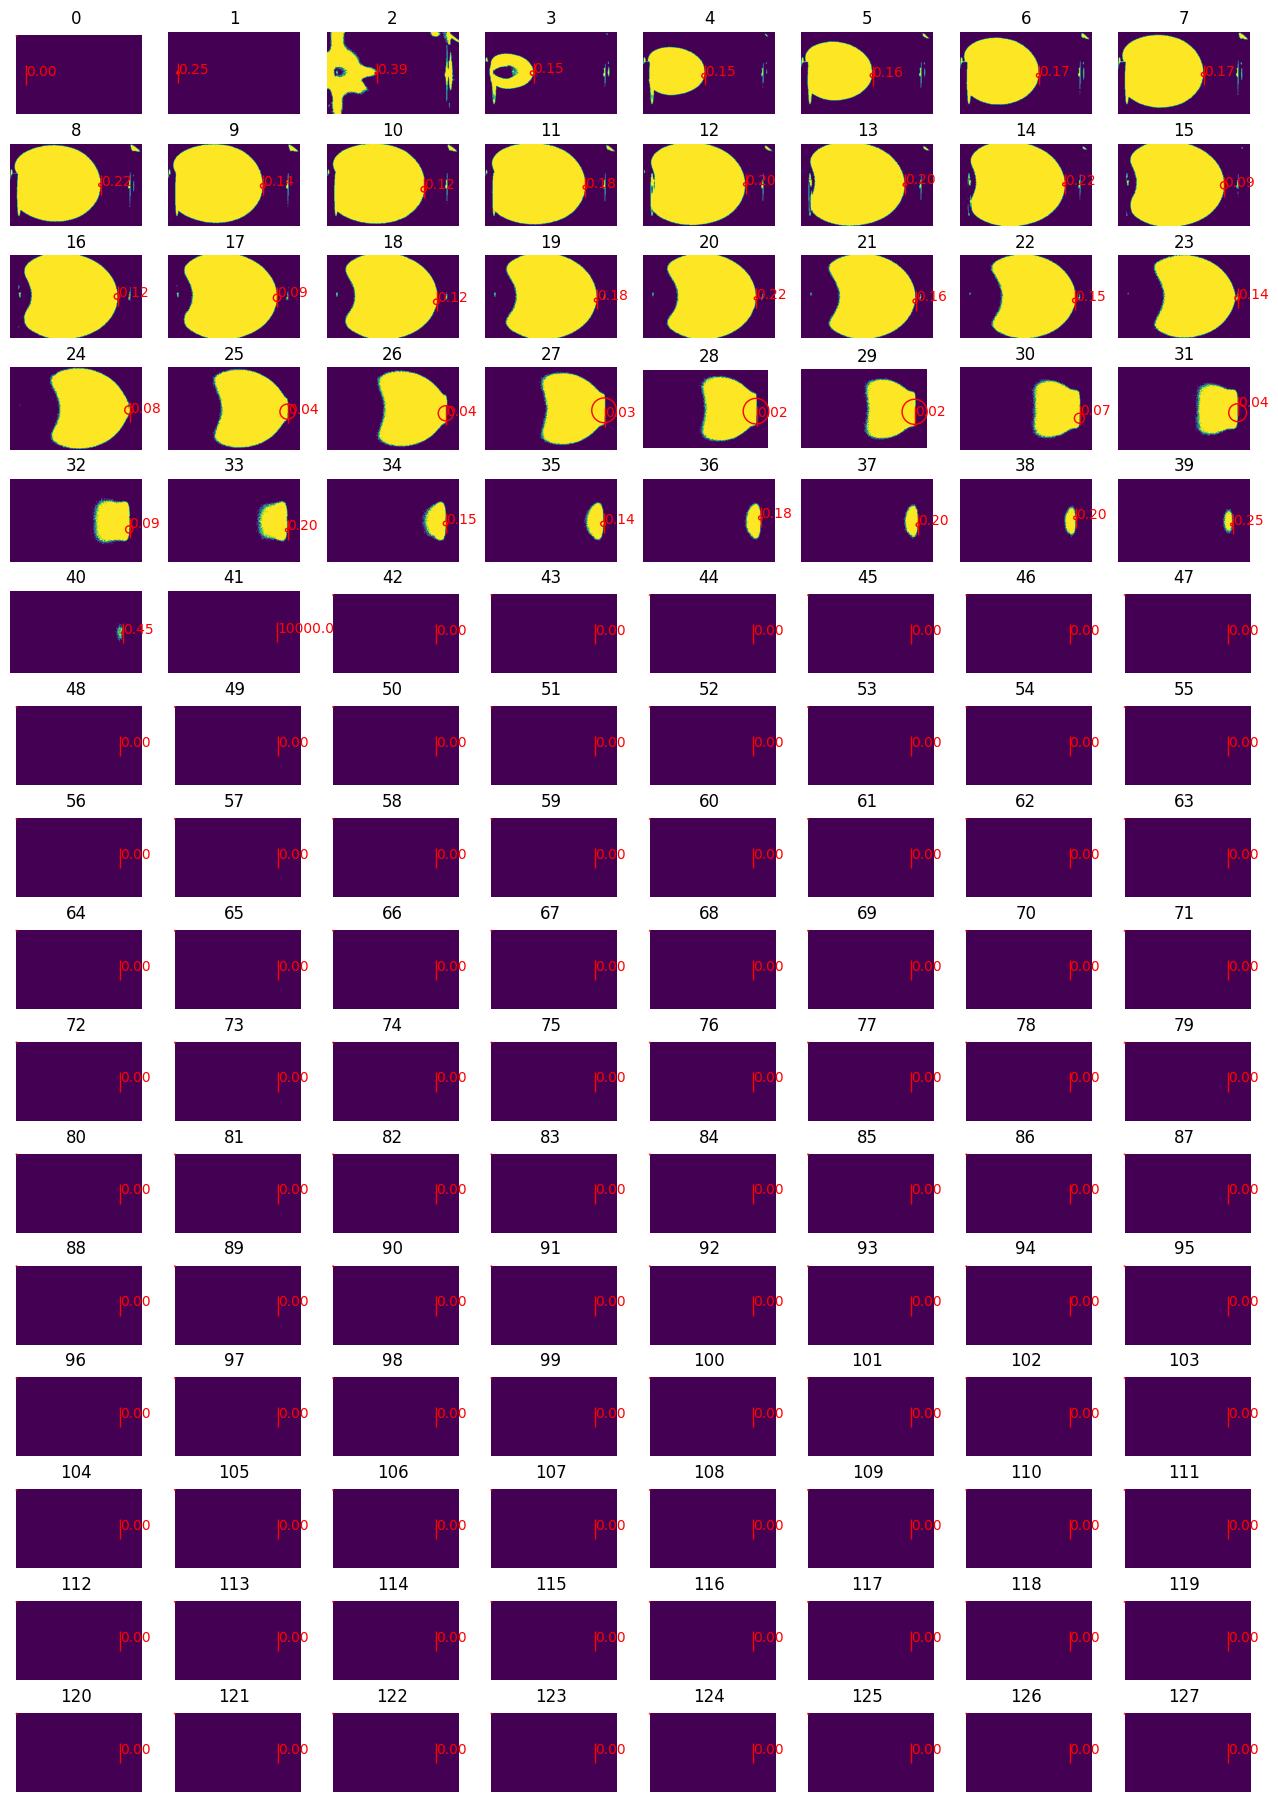

In [10]:
plume_position = plume_positions[0]
plume = plumes[0]

curvatures, centers, radii = V.calculate_plume_curvature(plume, edge_width=5)

titles = np.arange(0, plume_position.shape[0])
fig, axes = create_axes_grid(len(plume), n_per_row=8, plot_height=1.4)
# fig, axes = plt.subplots(5, 8, figsize=(16, 10))
for i, ax in enumerate(axes.flatten()):

    _, mask = cv2.threshold(plume[i], 50, 255, cv2.THRESH_BINARY)

    x, y = plume_position[i]
    ax.imshow(mask)
    ax.plot(x, y, 'r|', markersize=15)

    circle = plt.Circle(centers[i], radii[i], color='r', fill=False)
    ax.add_patch(circle)
    ax.text(x, y, f'{curvatures[i]:.2f}', color='red')
    ax.axis('off')
    ax.set_title(titles[i])
plt.show()

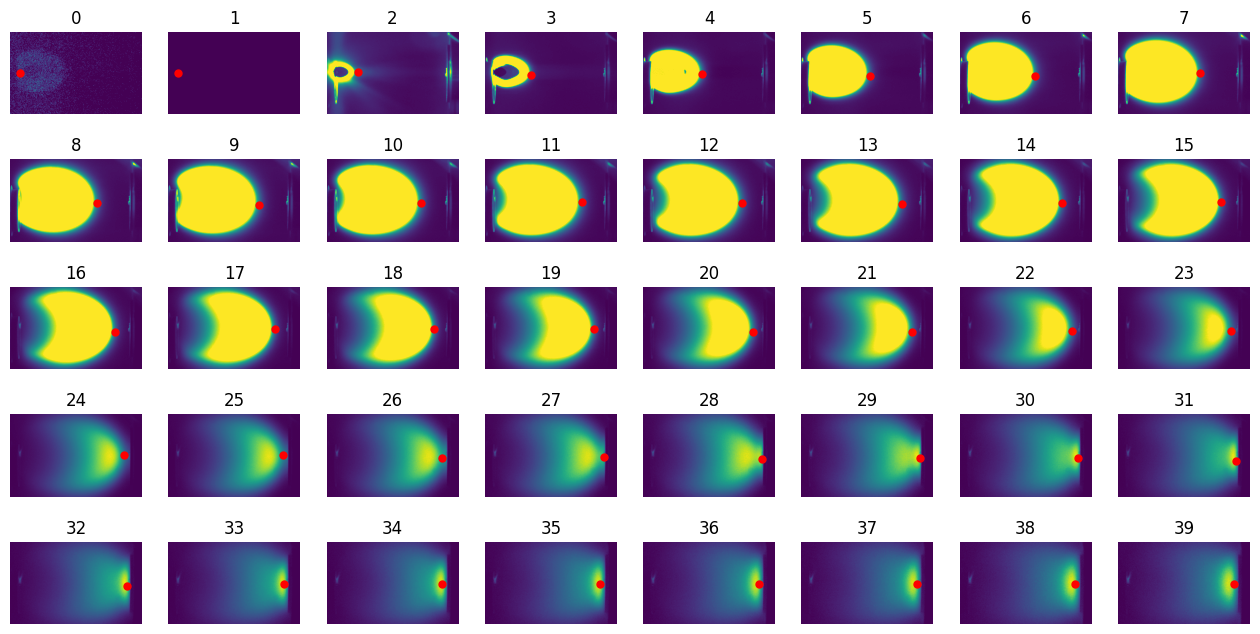

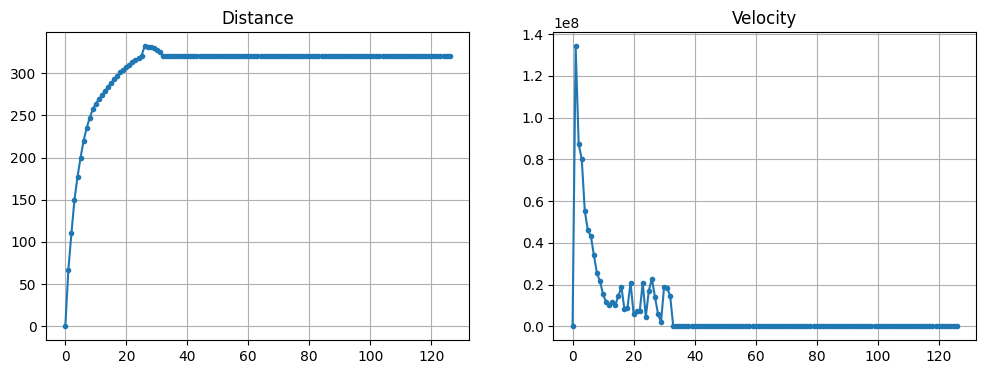

In [3]:
index = 0
V.visualize_plume_positions(plumes[index][:40], plume_positions[index][:40], label_time=False)
V.visualize_distance_velocity(plume_distances[index], plume_velocities[index], index_time=False)